(10000, 10)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  str    
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), str(1)
memory usage: 851.2 KB
None
is_fraud
0    0.9849
1    0.0151
Name: proportion, dtype: float64


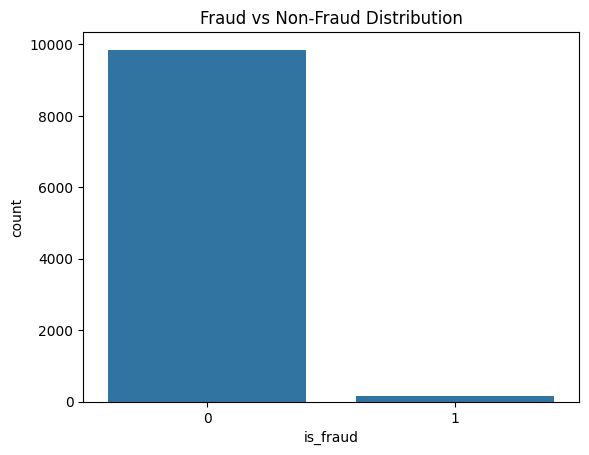

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("credit_card_fraud_10k.csv")   # replace with your file name
print(df.shape)
print(df.info())
print(df['is_fraud'].value_counts(normalize=True))

# Fraud vs Non-Fraud distribution
sns.countplot(x='is_fraud', data=df)
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()


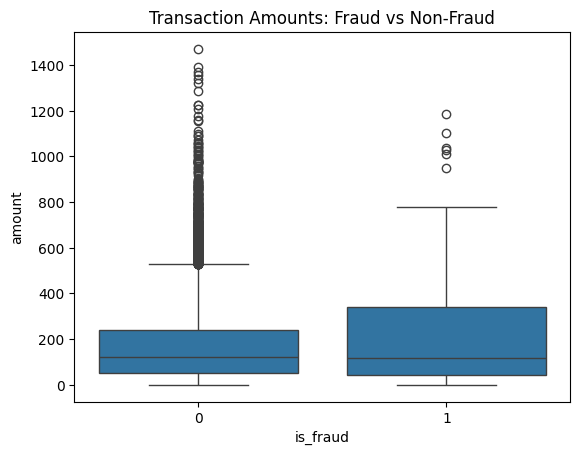

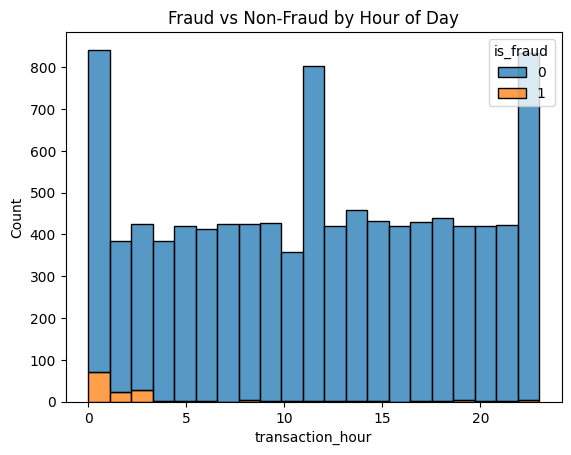

In [8]:
# Transaction amount distribution
sns.boxplot(x='is_fraud', y='amount', data=df)
plt.title("Transaction Amounts: Fraud vs Non-Fraud")
plt.show()

# Time-of-day analysis
sns.histplot(data=df, x='transaction_hour', hue='is_fraud', multiple='stack')
plt.title("Fraud vs Non-Fraud by Hour of Day")
plt.show()


In [ ]:
Fraud cases are <1% of transactions.

A model predicting “no fraud” for all cases would achieve >99% accuracy but be useless.

Precision, Recall, F1, and ROC-AUC are better metrics.

In [11]:
from sklearn.preprocessing import OneHotEncoder

# Separate features and target
X = df.drop(['transaction_id','is_fraud'], axis=1)
y = df['is_fraud']

# One-hot encode categorical columns
categorical_cols = ['merchant_category','foreign_transaction','location_mismatch']
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(X.head())


   amount  transaction_hour  device_trust_score  velocity_last_24h  \
0   84.47                22                  66                  3   
1  541.82                 3                  87                  1   
2  237.01                17                  49                  1   
3  164.33                 4                  72                  3   
4   30.53                15                  79                  0   

   cardholder_age  merchant_category_Electronics  merchant_category_Food  \
0              40                           True                   False   
1              64                          False                   False   
2              61                          False                   False   
3              34                          False                   False   
4              44                          False                    True   

   merchant_category_Grocery  merchant_category_Travel  foreign_transaction_1  \
0                      False             

In [12]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

print("Before SMOTE:", y.value_counts())
print("After SMOTE:", y_res.value_counts())


Before SMOTE: is_fraud
0    9849
1     151
Name: count, dtype: int64
After SMOTE: is_fraud
0    9849
1    9849
Name: count, dtype: int64


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, stratify=y_res, random_state=42
)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, stratify=y_res, random_state=42
)


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression (balanced class weights)
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# Random Forest
rf = RandomForestClassifier(class_weight='balanced', random_state=42)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [16]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

models = {'Logistic Regression': lr, 'Random Forest': rf}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))


--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1970
           1       0.98      0.99      0.99      1970

    accuracy                           0.99      3940
   macro avg       0.99      0.99      0.99      3940
weighted avg       0.99      0.99      0.99      3940

Confusion Matrix:
 [[1938   32]
 [  15 1955]]
ROC-AUC: 0.9993207761086347
--- Random Forest ---
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      1970
           1       0.99      1.00      1.00      1970

    accuracy                           1.00      3940
   macro avg       1.00      1.00      1.00      3940
weighted avg       1.00      1.00      1.00      3940

Confusion Matrix:
 [[1960   10]
 [   2 1968]]
ROC-AUC: 0.9999891777680434


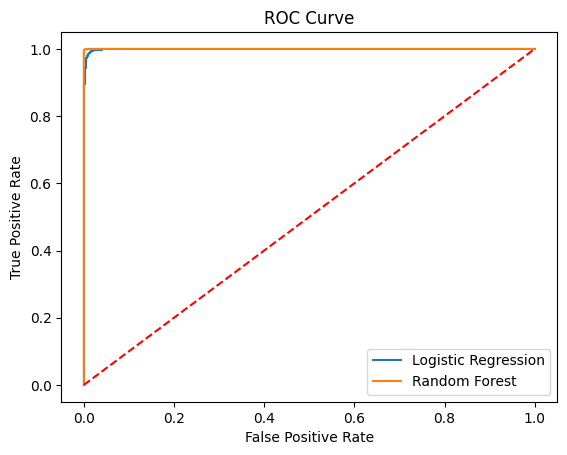

In [17]:
for name, model in models.items():
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


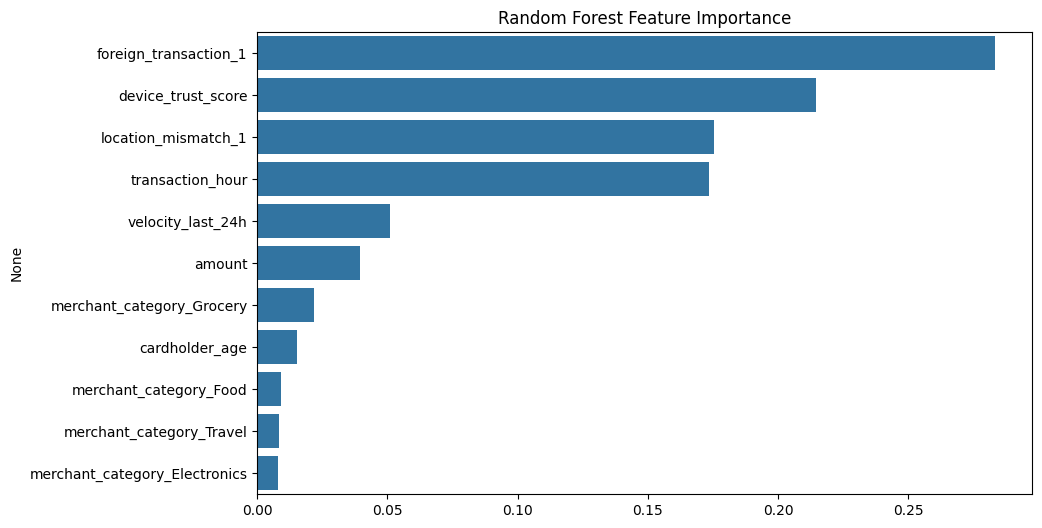

In [18]:
import numpy as np

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
sns.barplot(x=importances[indices], y=X.columns[indices])
plt.title("Random Forest Feature Importance")
plt.show()
